In [1]:
!git clone https://github.com/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints.git

Cloning into 'Pneumonia-Detection-Under-Imaging-Constraints'...
remote: Enumerating objects: 5928, done.
remote: Counting objects: 100% (75/75), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 5928 (delta 26), reused 37 (delta 8), pack-reused 5853 (from 1)
Receiving objects: 100% (5928/5928), 1.16 GiB | 32.32 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Updating files: 100% (5884/5884), done.


In [2]:
import sys
import os

sys.path.append(os.path.abspath("src"))

In [3]:
%cd /content/Pneumonia-Detection-Under-Imaging-Constraints

/content/Pneumonia-Detection-Under-Imaging-Constraints


In [4]:
import sys
print(sys.path[:5])

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload']


In [6]:
%cd /content/Pneumonia-Detection-Under-Imaging-Constraints
import sys
sys.path.append("/content/Pneumonia-Detection-Under-Imaging-Constraints")
from src.pixel_size_degradation import create_resolution_dataloaders

/content/Pneumonia-Detection-Under-Imaging-Constraints


In [7]:
!pwd

/content/Pneumonia-Detection-Under-Imaging-Constraints


In [8]:
!ls src

dataset_generation.py	      pixel_size_degradation.py
gaussian_blur_degradation.py  __pycache__


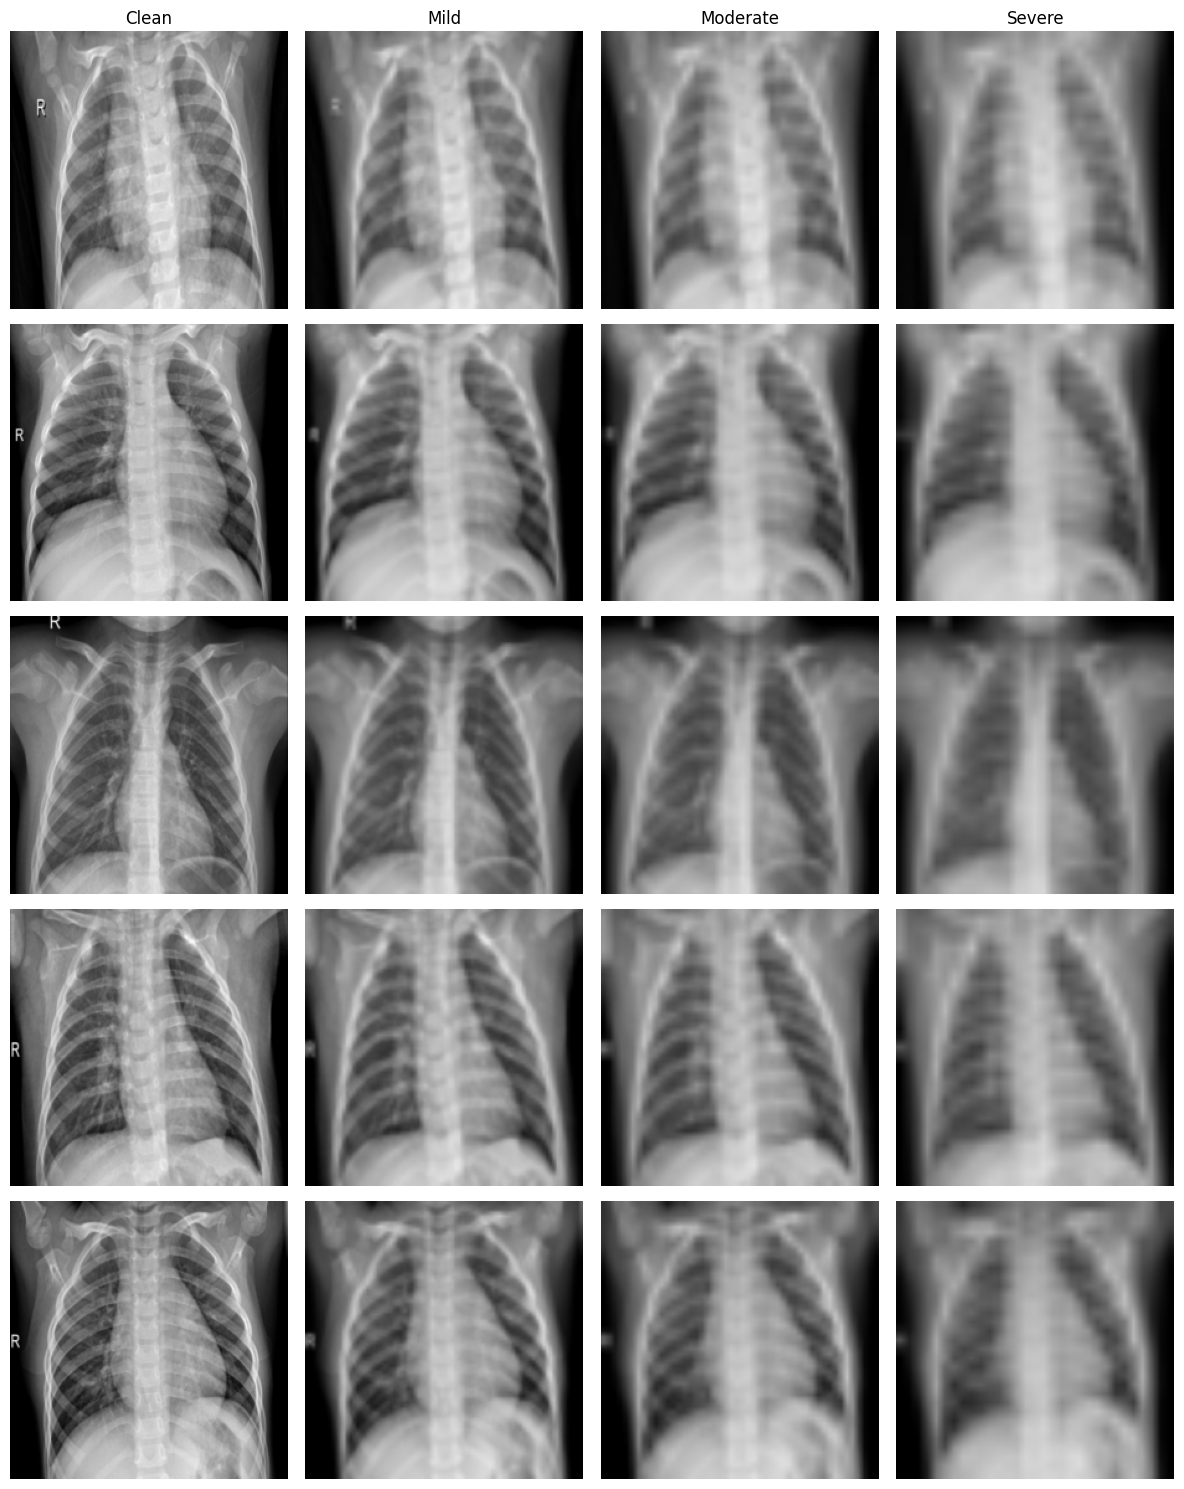

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------
# Import your dataset generator
# -----------------------------------
from src.pixel_size_degradation import create_resolution_dataloaders

# -----------------------------------
# Load datasets
# -----------------------------------
base_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/data"

clean_loaders, degraded_loader_sets = create_resolution_dataloaders(
    base_path=base_path,
    batch_size=8,
    degradation_levels={
        "mild": 0.3641,
        "moderate": 0.2162,
        "severe": 0.1396,
    }
)

# -----------------------------------
# Helper: unnormalize for plotting
# -----------------------------------
def unnormalize(img):
    img = img * 0.5 + 0.5  # assuming Normalize((0.5,), (0.5,))
    return np.clip(img, 0, 1)

# -----------------------------------
# Get ONE batch (same indices across datasets)
# -----------------------------------
clean_batch = next(iter(clean_loaders["test"]))
images_clean, labels = clean_batch

# grab matching degraded batches
images_mild = next(iter(degraded_loader_sets["mild"]["test"]))[0]
images_moderate = next(iter(degraded_loader_sets["moderate"]["test"]))[0]
images_severe = next(iter(degraded_loader_sets["severe"]["test"]))[0]

# -----------------------------------
# Plot comparison
# -----------------------------------
num_images = 5  # how many samples to show

fig, axes = plt.subplots(num_images, 4, figsize=(12, 3 * num_images))

titles = ["Clean", "Mild", "Moderate", "Severe"]

for i in range(num_images):
    imgs = [
        images_clean[i],
        images_mild[i],
        images_moderate[i],
        images_severe[i],
    ]

    for j in range(4):
        img = imgs[j].permute(1, 2, 0).cpu().numpy()
        img = unnormalize(img)

        axes[i, j].imshow(img.squeeze(), cmap="gray")
        axes[i, j].axis("off")

        if i == 0:
            axes[i, j].set_title(titles[j])

plt.tight_layout()
plt.show()

In [12]:
import os
import torch
import torch.nn as nn
from torchvision.models import densenet121

# -----------------------------
# Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# Rebuild model architecture
# -----------------------------
model = densenet121(weights=None)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)
model = model.to(device)

# -----------------------------
# Load saved weights
# -----------------------------
weights_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/results/baseline_densenet_classweighted/model_weights.pth"

state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("Model weights loaded successfully.")

Using device: cuda
Model weights loaded successfully.


In [13]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model_full(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    if len(np.unique(all_labels)) == 2:
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = np.nan

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

In [14]:
import numpy as np

# example: from your train set counts
num_normal = 1341
num_pneumonia = 3875
total = num_normal + num_pneumonia

weight_normal = total / (2 * num_normal)
weight_pneumonia = total / (2 * num_pneumonia)

class_weights = torch.tensor(
    [weight_normal, weight_pneumonia],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [15]:
import pandas as pd

results = []

for level_name, loader_set in degraded_loader_sets.items():
    test_loader = loader_set["test"]

    metrics = evaluate_model_full(model, test_loader, criterion, device)

    results.append({
        "degradation_level": level_name,
        "scale_factor": loader_set["scale_factor"],
        "loss": metrics["loss"],
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "auc": metrics["auc"],
    })

results_df = pd.DataFrame(results).sort_values("scale_factor", ascending=False)
results_df

,degradation_level,scale_factor,loss,accuracy,balanced_accuracy,precision,recall,f1,auc
0,mild,0.3641,1.654320,0.671474,0.561966,0.655462,1.0,0.791878,0.890927
1,moderate,0.2162,2.167601,0.636218,0.514957,0.632091,1.0,0.774578,0.845009
2,severe,0.1396,2.509578,0.628205,0.504274,0.627010,1.0,0.770751,0.794318


In [16]:
print(results_df.to_string(index=False))

degradation_level  scale_factor     loss  accuracy  balanced_accuracy  precision  recall       f1      auc
             mild        0.3641 1.654320  0.671474           0.561966   0.655462     1.0 0.791878 0.890927
         moderate        0.2162 2.167601  0.636218           0.514957   0.632091     1.0 0.774578 0.845009
           severe        0.1396 2.509578  0.628205           0.504274   0.627010     1.0 0.770751 0.794318


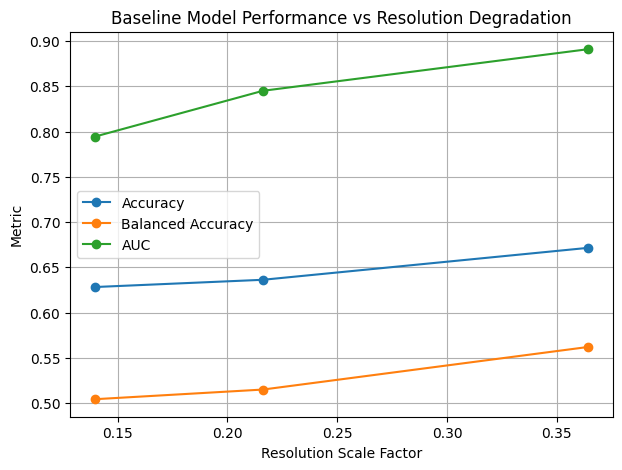

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.plot(results_df["scale_factor"], results_df["accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["scale_factor"], results_df["balanced_accuracy"], marker="o", label="Balanced Accuracy")
plt.plot(results_df["scale_factor"], results_df["auc"], marker="o", label="AUC")

plt.xlabel("Resolution Scale Factor")
plt.ylabel("Metric")
plt.title("Baseline Model Performance vs Resolution Degradation")
plt.legend()
plt.grid(True)
plt.show()

Using device: cuda
Training on degraded dataset: mild
Train samples: 5216
Val samples: 16
Test samples: 624
Class counts:
  NORMAL (0): 1341
  PNEUMONIA (1): 3875
Class weights: tensor([1.9448, 0.6730], device='cuda:0')
Epoch 01/8 | Train Loss: 0.2221 | Train Acc: 0.9107 | Test Loss: 0.3549 | Test Acc: 0.8494 | Val Loss: 0.6310 | Val Acc: 0.6875
Epoch 02/8 | Train Loss: 0.1231 | Train Acc: 0.9557 | Test Loss: 0.3809 | Test Acc: 0.8510 | Val Loss: 0.6550 | Val Acc: 0.7500
Epoch 03/8 | Train Loss: 0.0932 | Train Acc: 0.9645 | Test Loss: 0.5829 | Test Acc: 0.8109 | Val Loss: 0.4720 | Val Acc: 0.8125
Epoch 04/8 | Train Loss: 0.0713 | Train Acc: 0.9728 | Test Loss: 0.4023 | Test Acc: 0.8750 | Val Loss: 0.3964 | Val Acc: 0.9375
Epoch 05/8 | Train Loss: 0.0543 | Train Acc: 0.9822 | Test Loss: 0.7906 | Test Acc: 0.7965 | Val Loss: 0.1425 | Val Acc: 0.9375
Epoch 06/8 | Train Loss: 0.0603 | Train Acc: 0.9785 | Test Loss: 0.5736 | Test Acc: 0.8125 | Val Loss: 0.1111 | Val Acc: 1.0000
Epoch 07/8 |

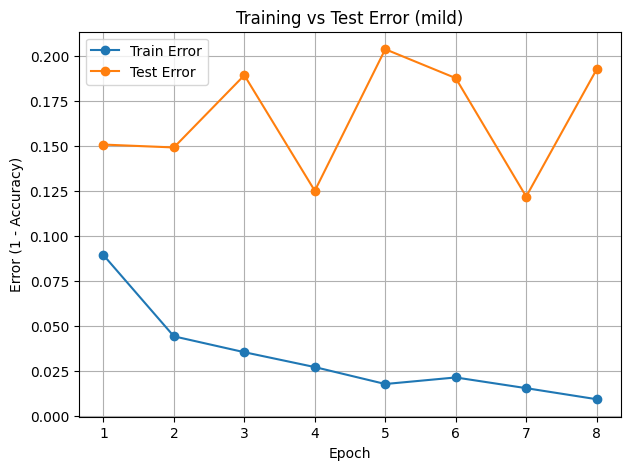

In [18]:
# =========================
# Train baseline DenseNet on ONE degraded dataset
# =========================

import os
import copy
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    balanced_accuracy_score,
)
from torchvision.models import densenet121

# -----------------------------------
# Load degraded datasets
# -----------------------------------
from src.pixel_size_degradation import create_resolution_dataloaders

base_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/data"

clean_loaders, degraded_loader_sets = create_resolution_dataloaders(
    base_path=base_path,
    batch_size=32,   # match baseline
    degradation_levels={
        "mild": 0.3641,
        "moderate": 0.2162,
        "severe": 0.1396,
    }
)

# -----------------------------------
# Choose which degraded dataset to train on
# -----------------------------------
degradation_name = "mild"   # change to "moderate" or "severe"

train_loader = degraded_loader_sets[degradation_name]["train"]
val_loader   = degraded_loader_sets[degradation_name]["val"]
test_loader  = degraded_loader_sets[degradation_name]["test"]

# -----------------------------------
# Baseline config
# -----------------------------------
num_epochs = 8
lr = 1e-4
weight_decay = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)
print(f"Training on degraded dataset: {degradation_name}")
print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))

# -----------------------------------
# Compute class weights from training set
# -----------------------------------
train_labels = np.array(train_loader.dataset.labels)

num_normal = np.sum(train_labels == 0)
num_pneumonia = np.sum(train_labels == 1)
total = len(train_labels)

weight_normal = total / (2 * num_normal)
weight_pneumonia = total / (2 * num_pneumonia)

class_weights = torch.tensor(
    [weight_normal, weight_pneumonia],
    dtype=torch.float32
).to(device)

print("Class counts:")
print(f"  NORMAL (0): {num_normal}")
print(f"  PNEUMONIA (1): {num_pneumonia}")
print("Class weights:", class_weights)

# -----------------------------------
# Build DenseNet-121 exactly like baseline
# -----------------------------------
model = densenet121(weights=None)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)
model = model.to(device)

# -----------------------------------
# Loss / optimizer
# -----------------------------------
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

# -----------------------------------
# Evaluation function
# -----------------------------------
def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    if len(np.unique(all_labels)) == 2:
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = np.nan

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

# -----------------------------------
# Training loop
# -----------------------------------
history = {
    "train_loss": [],
    "test_loss": [],
    "train_acc": [],
    "test_acc": [],
    "val_loss": [],
    "val_acc": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_loss = float("inf")

start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total_seen = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total_seen += labels.size(0)

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = correct / total_seen

    test_metrics = evaluate_model(model, test_loader, criterion, device)
    val_metrics = evaluate_model(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_metrics["loss"])
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_metrics["accuracy"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_acc"].append(val_metrics["accuracy"])

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_wts = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Test Loss: {test_metrics['loss']:.4f} | Test Acc: {test_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f}"
    )

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.2f} minutes")

# -----------------------------------
# Load best model by val loss
# -----------------------------------
model.load_state_dict(best_model_wts)

# -----------------------------------
# Final metrics
# -----------------------------------
final_val_metrics = evaluate_model(model, val_loader, criterion, device)
final_test_metrics = evaluate_model(model, test_loader, criterion, device)

balanced_acc = balanced_accuracy_score(
    final_test_metrics["labels"],
    final_test_metrics["preds"]
)

print("\n===== FINAL VALIDATION METRICS =====")
print(f"Loss      : {final_val_metrics['loss']:.4f}")
print(f"Accuracy  : {final_val_metrics['accuracy']:.4f}")
print(f"Precision : {final_val_metrics['precision']:.4f}")
print(f"Recall    : {final_val_metrics['recall']:.4f}")
print(f"F1        : {final_val_metrics['f1']:.4f}")
print(f"AUC       : {final_val_metrics['auc']:.4f}")
print("Confusion matrix:")
print(final_val_metrics["confusion_matrix"])

print("\n===== FINAL TEST METRICS =====")
print(f"Loss              : {final_test_metrics['loss']:.4f}")
print(f"Accuracy          : {final_test_metrics['accuracy']:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"Precision         : {final_test_metrics['precision']:.4f}")
print(f"Recall            : {final_test_metrics['recall']:.4f}")
print(f"F1 Score          : {final_test_metrics['f1']:.4f}")
print(f"AUC               : {final_test_metrics['auc']:.4f}")
print("Confusion matrix:")
print(final_test_metrics["confusion_matrix"])

# -----------------------------------
# Plot train vs test error
# -----------------------------------
train_error = [1 - acc for acc in history["train_acc"]]
test_error = [1 - acc for acc in history["test_acc"]]

plt.figure(figsize=(7, 5))
plt.plot(range(1, num_epochs + 1), train_error, marker="o", label="Train Error")
plt.plot(range(1, num_epochs + 1), test_error, marker="o", label="Test Error")
plt.xlabel("Epoch")
plt.ylabel("Error (1 - Accuracy)")
plt.title(f"Training vs Test Error ({degradation_name})")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def train_baseline_on_loader(loaders, condition_name,
                             num_epochs=8, lr=1e-4, weight_decay=1e-4):

    import copy, time
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torchvision.models import densenet121
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score,
        f1_score, roc_auc_score, confusion_matrix,
        balanced_accuracy_score
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = loaders["train"]
    val_loader   = loaders["val"]
    test_loader  = loaders["test"]

    print(f"\n=== Training: {condition_name} ===")

    # -------------------------
    # Class weights
    # -------------------------
    train_labels = np.array(train_loader.dataset.labels)

    num_normal = np.sum(train_labels == 0)
    num_pneumonia = np.sum(train_labels == 1)
    total = len(train_labels)

    class_weights = torch.tensor([
        total / (2 * num_normal),
        total / (2 * num_pneumonia)
    ], dtype=torch.float32).to(device)

    # -------------------------
    # Model
    # -------------------------
    model = densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, 2)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # -------------------------
    # Eval function
    # -------------------------
    def evaluate(loader):
        model.eval()
        all_labels, all_preds, all_probs = [], [], []
        running_loss = 0.0

        with torch.no_grad():
            for images, labels in loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)

                probs = torch.softmax(outputs, dim=1)[:, 1]
                preds = torch.argmax(outputs, dim=1)

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())

        loss = running_loss / len(loader.dataset)

        return {
            "loss": loss,
            "accuracy": accuracy_score(all_labels, all_preds),
            "precision": precision_score(all_labels, all_preds, zero_division=0),
            "recall": recall_score(all_labels, all_preds, zero_division=0),
            "f1": f1_score(all_labels, all_preds, zero_division=0),
            "auc": roc_auc_score(all_labels, all_probs),
            "labels": np.array(all_labels),
            "preds": np.array(all_preds),
        }

    # -------------------------
    # Training loop
    # -------------------------
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")

    history = {"train_acc": [], "test_acc": []}

    for epoch in range(num_epochs):
        model.train()
        correct = 0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_seen += labels.size(0)

        train_acc = correct / total_seen
        val_metrics = evaluate(val_loader)
        test_metrics = evaluate(test_loader)

        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_metrics["accuracy"])

        if val_metrics["loss"] < best_val_loss:
            best_val_loss = val_metrics["loss"]
            best_model_wts = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Test Acc={test_metrics['accuracy']:.4f}")

    # load best model
    model.load_state_dict(best_model_wts)

    final_test = evaluate(test_loader)

    balanced_acc = balanced_accuracy_score(
        final_test["labels"], final_test["preds"]
    )

    print(f"\nFinal Test Accuracy: {final_test['accuracy']:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")

    return model, history, final_test

In [20]:
model_moderate, history_moderate, results_moderate = train_baseline_on_loader(
    degraded_loader_sets["moderate"],
    "moderate"
)


=== Training: moderate ===
Epoch 1: Train Acc=0.9132, Test Acc=0.8766
Epoch 2: Train Acc=0.9586, Test Acc=0.8590
Epoch 3: Train Acc=0.9659, Test Acc=0.8045
Epoch 4: Train Acc=0.9728, Test Acc=0.7468
Epoch 5: Train Acc=0.9799, Test Acc=0.8686
Epoch 6: Train Acc=0.9816, Test Acc=0.8718
Epoch 7: Train Acc=0.9854, Test Acc=0.8574
Epoch 8: Train Acc=0.9879, Test Acc=0.8333

Final Test Accuracy: 0.8574
Balanced Accuracy: 0.8158


In [22]:
print("\n===== MODERATE TEST METRICS =====")

print(f"Loss       : {results_moderate['loss']:.4f}")
print(f"Accuracy   : {results_moderate['accuracy']:.4f}")
print(f"Precision  : {results_moderate['precision']:.4f}")
print(f"Recall     : {results_moderate['recall']:.4f}")
print(f"F1 Score   : {results_moderate['f1']:.4f}")
print(f"AUC        : {results_moderate['auc']:.4f}")


===== MODERATE TEST METRICS =====
Loss       : 0.5437
Accuracy   : 0.8574
Precision  : 0.8237
Recall     : 0.9821
F1 Score   : 0.8959
AUC        : 0.9475


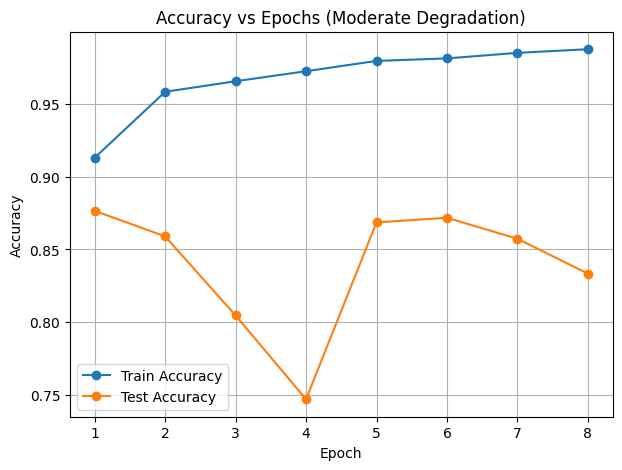

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_moderate["train_acc"]) + 1)

plt.figure(figsize=(7,5))

plt.plot(epochs, history_moderate["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs, history_moderate["test_acc"], marker='o', label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (Moderate Degradation)")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    results_moderate["labels"],
    results_moderate["preds"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[152  82]
 [  7 383]]


In [24]:
model_severe, history_severe, results_severe = train_baseline_on_loader(
    degraded_loader_sets["severe"],
    "severe"
)


=== Training: severe ===
Epoch 1: Train Acc=0.9128, Test Acc=0.8638
Epoch 2: Train Acc=0.9544, Test Acc=0.8478
Epoch 3: Train Acc=0.9576, Test Acc=0.8494
Epoch 4: Train Acc=0.9651, Test Acc=0.8574
Epoch 5: Train Acc=0.9712, Test Acc=0.8782
Epoch 6: Train Acc=0.9764, Test Acc=0.8542
Epoch 7: Train Acc=0.9858, Test Acc=0.8462
Epoch 8: Train Acc=0.9833, Test Acc=0.7821

Final Test Accuracy: 0.8782
Balanced Accuracy: 0.8504


In [27]:
print("\n===== SEVERE TEST METRICS =====")

print(f"Loss       : {results_severe['loss']:.4f}")
print(f"Accuracy   : {results_severe['accuracy']:.4f}")
print(f"Precision  : {results_severe['precision']:.4f}")
print(f"Recall     : {results_severe['recall']:.4f}")
print(f"F1 Score   : {results_severe['f1']:.4f}")
print(f"AUC        : {results_severe['auc']:.4f}")


===== SEVERE TEST METRICS =====
Loss       : 0.3390
Accuracy   : 0.8782
Precision  : 0.8601
Recall     : 0.9615
F1 Score   : 0.9080
AUC        : 0.9562


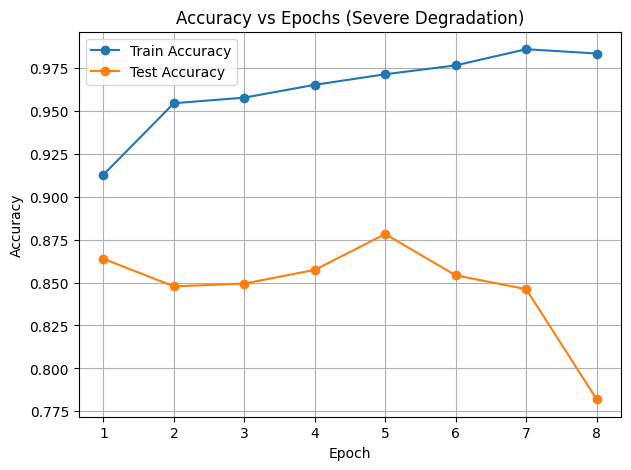

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_severe["train_acc"]) + 1)

plt.figure(figsize=(7,5))

plt.plot(epochs, history_severe["train_acc"], marker='o', label="Train Accuracy")
plt.plot(epochs, history_severe["test_acc"], marker='o', label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (Severe Degradation)")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    results_severe["labels"],
    results_severe["preds"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[173  61]
 [ 15 375]]
